In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Train Test Split
from sklearn.model_selection import train_test_split

# Handling Imbalanced Data
from imblearn.over_sampling import SMOTE

# Baseline Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# XGBoost
from xgboost import XGBClassifier

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("/content/flights_sample_100k.csv")

In [6]:
df

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-03-01,Allegiant Air,Allegiant Air: G4,G4,20368,1668,PGD,"Punta Gorda, FL",SPI,"Springfield, IL",...,0.0,160.0,138.0,122.0,994.0,NaN,NaN,NaN,NaN,NaN
1,2021-02-16,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,2437,DFW,"Dallas/Fort Worth, TX",LAX,"Los Angeles, CA",...,0.0,211.0,NaN,NaN,1235.0,NaN,NaN,NaN,NaN,NaN
2,2022-04-12,PSA Airlines Inc.,PSA Airlines Inc.: OH,OH,20397,5560,EWN,"New Bern/Morehead/Beaufort, NC",CLT,"Charlotte, NC",...,0.0,79.0,78.0,51.0,221.0,NaN,NaN,NaN,NaN,NaN
3,2021-10-13,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,1944,ABQ,"Albuquerque, NM",DEN,"Denver, CO",...,0.0,80.0,71.0,49.0,349.0,10.0,0.0,0.0,0.0,6.0
4,2022-06-05,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,3081,PIT,"Pittsburgh, PA",STL,"St. Louis, MO",...,0.0,105.0,100.0,82.0,554.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2019-02-26,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2229,CHS,"Charleston, SC",ATL,"Atlanta, GA",...,0.0,84.0,73.0,50.0,259.0,NaN,NaN,NaN,NaN,NaN
99996,2023-02-10,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,2977,MDW,"Chicago, IL",LAX,"Los Angeles, CA",...,0.0,280.0,239.0,209.0,1750.0,88.0,0.0,0.0,0.0,0.0
99997,2019-06-26,Endeavor Air Inc.,Endeavor Air Inc.: 9E,9E,20363,5003,ORF,"Norfolk, VA",JFK,"New York, NY",...,0.0,93.0,82.0,51.0,290.0,NaN,NaN,NaN,NaN,NaN
99998,2023-06-22,Endeavor Air Inc.,Endeavor Air Inc.: 9E,9E,20363,5173,CVG,"Cincinnati, OH",LGA,"New York, NY",...,0.0,127.0,110.0,87.0,585.0,NaN,NaN,NaN,NaN,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   FL_DATE                  100000 non-null  object 
 1   AIRLINE                  100000 non-null  object 
 2   AIRLINE_DOT              100000 non-null  object 
 3   AIRLINE_CODE             100000 non-null  object 
 4   DOT_CODE                 100000 non-null  int64  
 5   FL_NUMBER                100000 non-null  int64  
 6   ORIGIN                   100000 non-null  object 
 7   ORIGIN_CITY              100000 non-null  object 
 8   DEST                     100000 non-null  object 
 9   DEST_CITY                100000 non-null  object 
 10  CRS_DEP_TIME             100000 non-null  int64  
 11  DEP_TIME                 97424 non-null   float64
 12  DEP_DELAY                97423 non-null   float64
 13  TAXI_OUT                 97382 non-null   float64
 14  WHEEL

In [9]:
for col in df.columns:
    print(col)

FL_DATE
AIRLINE
AIRLINE_DOT
AIRLINE_CODE
DOT_CODE
FL_NUMBER
ORIGIN
ORIGIN_CITY
DEST
DEST_CITY
CRS_DEP_TIME
DEP_TIME
DEP_DELAY
TAXI_OUT
WHEELS_OFF
WHEELS_ON
TAXI_IN
CRS_ARR_TIME
ARR_TIME
ARR_DELAY
CANCELLED
CANCELLATION_CODE
DIVERTED
CRS_ELAPSED_TIME
ELAPSED_TIME
AIR_TIME
DISTANCE
DELAY_DUE_CARRIER
DELAY_DUE_WEATHER
DELAY_DUE_NAS
DELAY_DUE_SECURITY
DELAY_DUE_LATE_AIRCRAFT


In [10]:
df["ARR_DELAY"].describe()

,ARR_DELAY
count,97148.000000
mean,4.353759
std,51.360244
min,-88.000000
25%,-15.000000
50%,-7.000000
75%,7.000000
max,1520.000000


In [11]:
df["CANCELLED"].value_counts()

,count
CANCELLED,
0.0,97373
1.0,2627


In [12]:
# Keep only flights that were not cancelled
df = df[df["CANCELLED"] == 0]

print(df.shape)

(97373, 32)


In [13]:
# Create Target Variable
df["Delayed"] = (df["ARR_DELAY"] >= 15).astype(int)

# Check first rows
df[["ARR_DELAY", "Delayed"]].head()

,ARR_DELAY,Delayed
0,-32.0,0
2,-8.0,0
3,16.0,1
4,-5.0,0
5,-22.0,0


In [14]:
df["Delayed"].value_counts()

,count
Delayed,
0,79381
1,17992


In [15]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

,0
CANCELLATION_CODE,97373
DELAY_DUE_WEATHER,79381
DELAY_DUE_CARRIER,79381
DELAY_DUE_NAS,79381
DELAY_DUE_SECURITY,79381
DELAY_DUE_LATE_AIRCRAFT,79381
AIR_TIME,225
ARR_DELAY,225
ELAPSED_TIME,225
ARR_TIME,28


In [16]:
columns_to_drop = [
    "CANCELLATION_CODE",
    "DELAY_DUE_CARRIER",
    "DELAY_DUE_WEATHER",
    "DELAY_DUE_NAS",
    "DELAY_DUE_SECURITY",
    "DELAY_DUE_LATE_AIRCRAFT"
]

df.drop(columns=columns_to_drop, inplace=True)

print(df.shape)

(97373, 27)


In [17]:
columns_to_drop = [
    "ARR_DELAY",
    "ARR_TIME",
    "AIR_TIME",
    "ELAPSED_TIME",
    "WHEELS_ON",
    "TAXI_IN"
]

df.drop(columns=columns_to_drop, inplace=True)

print(df.shape)

(97373, 21)


In [22]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

,0


In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])

df["FL_DATE"].dtype

dtype('<M8[ns]')

**EDA**

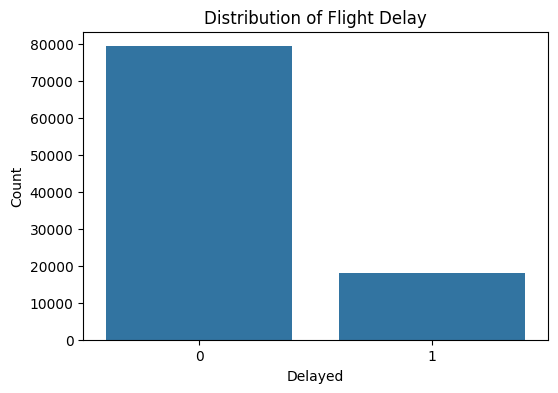

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Delayed")

plt.title("Distribution of Flight Delay")
plt.xlabel("Delayed")
plt.ylabel("Count")

plt.show()

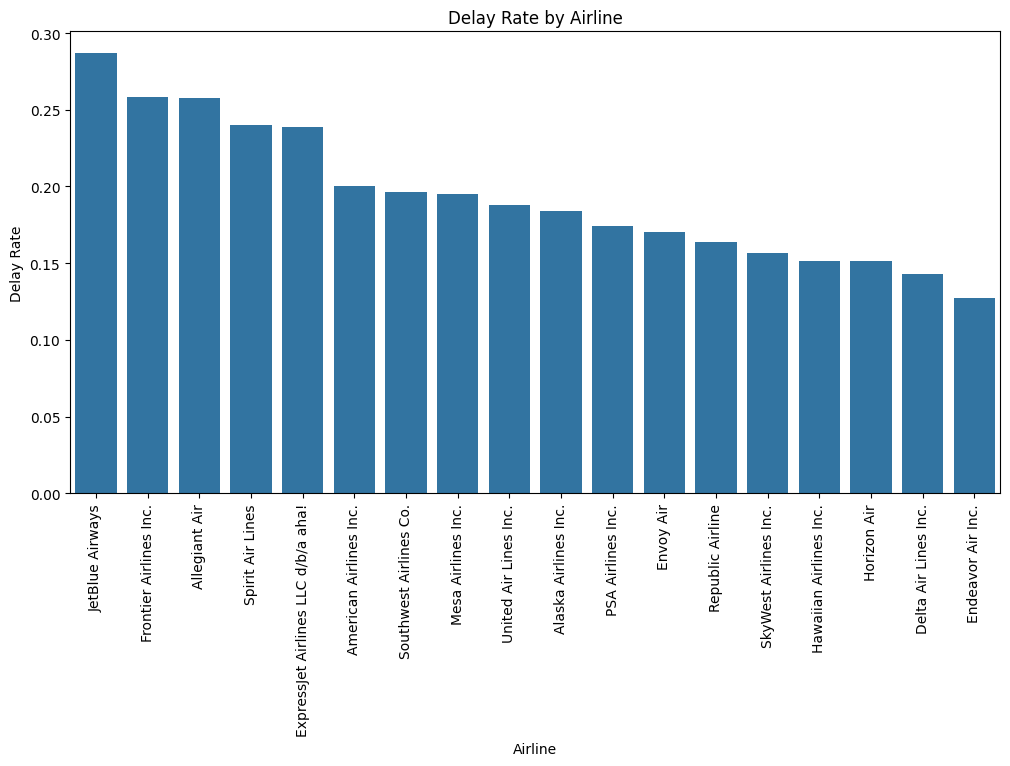

In [26]:
airline_delay = (
    df.groupby("AIRLINE")["Delayed"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=airline_delay.index,
    y=airline_delay.values
)

plt.xticks(rotation=90)
plt.title("Delay Rate by Airline")
plt.xlabel("Airline")
plt.ylabel("Delay Rate")

plt.show()

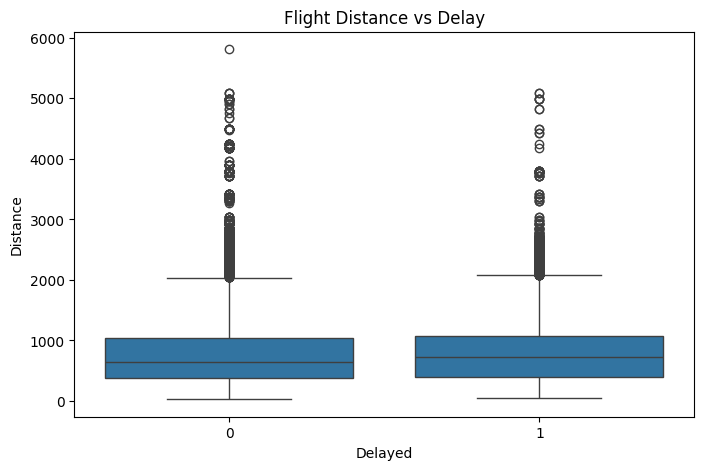

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Delayed",
    y="DISTANCE"
)

plt.title("Flight Distance vs Delay")
plt.xlabel("Delayed")
plt.ylabel("Distance")

plt.show()

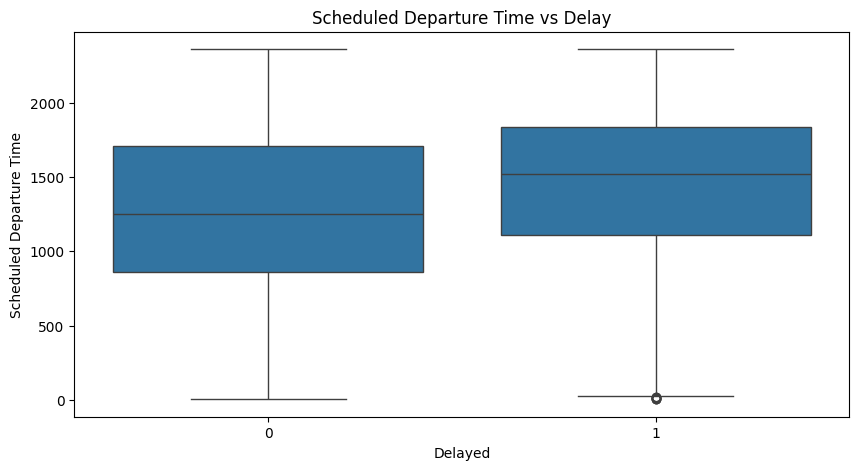

In [28]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Delayed",
    y="CRS_DEP_TIME"
)

plt.title("Scheduled Departure Time vs Delay")
plt.xlabel("Delayed")
plt.ylabel("Scheduled Departure Time")

plt.show()

In [29]:
# Extract date features
df["Month"] = df["FL_DATE"].dt.month
df["DayOfWeek"] = df["FL_DATE"].dt.dayofweek

# Display the new features
df[["FL_DATE", "Month", "DayOfWeek"]].head()

,FL_DATE,Month,DayOfWeek
0,2019-03-01,3,4
2,2022-04-12,4,1
3,2021-10-13,10,2
4,2022-06-05,6,6
5,2019-10-06,10,6


In [30]:
# Extract departure hour from scheduled departure time
df["Departure_Hour"] = df["CRS_DEP_TIME"] // 100

# Display the result
df[["CRS_DEP_TIME", "Departure_Hour"]].head()

,CRS_DEP_TIME,Departure_Hour
0,630,6
2,625,6
3,1715,17
4,535,5
5,1140,11


In [31]:
columns_to_drop = [
    "FL_DATE",
    "CRS_DEP_TIME",
    "DEP_TIME",
    "DEP_DELAY",
    "TAXI_OUT",
    "WHEELS_OFF",
    "DIVERTED"
]

df.drop(columns=columns_to_drop, inplace=True)

print(df.columns)
print(df.shape)

Index(['AIRLINE', 'AIRLINE_DOT', 'AIRLINE_CODE', 'DOT_CODE', 'FL_NUMBER',
       'ORIGIN', 'ORIGIN_CITY', 'DEST', 'DEST_CITY', 'CRS_ARR_TIME',
       'CANCELLED', 'CRS_ELAPSED_TIME', 'DISTANCE', 'Delayed', 'Month',
       'DayOfWeek', 'Departure_Hour'],
      dtype='object')
(97373, 17)


In [32]:
df.drop(
    columns=["AIRLINE_DOT", "AIRLINE_CODE", "CANCELLED"],
    inplace=True
)

print(df.columns)
print(df.shape)

Index(['AIRLINE', 'DOT_CODE', 'FL_NUMBER', 'ORIGIN', 'ORIGIN_CITY', 'DEST',
       'DEST_CITY', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE', 'Delayed',
       'Month', 'DayOfWeek', 'Departure_Hour'],
      dtype='object')
(97373, 14)


In [33]:
# Remove redundant columns
df.drop(columns=["ORIGIN_CITY", "DEST_CITY"], inplace=True)

print(df.columns)
print(df.shape)

Index(['AIRLINE', 'DOT_CODE', 'FL_NUMBER', 'ORIGIN', 'DEST', 'CRS_ARR_TIME',
       'CRS_ELAPSED_TIME', 'DISTANCE', 'Delayed', 'Month', 'DayOfWeek',
       'Departure_Hour'],
      dtype='object')
(97373, 12)


**Preprocessing**

In [35]:
# Features and Target
X = df.drop(columns="Delayed")
y = df["Delayed"]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
# Numerical Features
numerical_features = X_train.select_dtypes(include="number").columns.tolist()

# Categorical Features
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['DOT_CODE', 'FL_NUMBER', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DISTANCE', 'Month', 'DayOfWeek', 'Departure_Hour']

Categorical Features:
['AIRLINE', 'ORIGIN', 'DEST']


In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [54]:
from sklearn.pipeline import Pipeline

# Logistic Regression Pipeline
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
))
    ]
)

In [55]:
# Train the model
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['AIRLINE', 'ORIGIN',
                                                   'DEST']),
                                                 ('num', StandardScaler(),
                                                  ['DOT_CODE', 'FL_NUMBER',
                                                   'CRS_ARR_TIME',
                                                   'CRS_ELAPSED_TIME',
                                                   'DISTANCE', 'Month',
                                                   'DayOfWeek',
                                                   'Departure_Hour'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [57]:
# Predict on test data
y_pred = logistic_pipeline.predict(X_test)

In [58]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5937


In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.59      0.70     15877
           1       0.25      0.59      0.35      3598

    accuracy                           0.59     19475
   macro avg       0.56      0.59      0.53     19475
weighted avg       0.75      0.59      0.64     19475



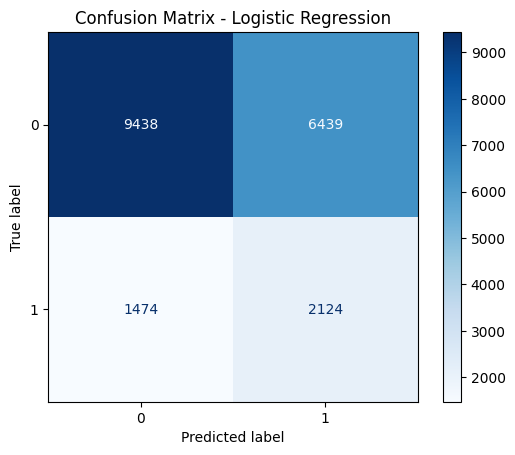

In [60]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [61]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [63]:
# Decision Tree Pipeline
tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

In [65]:
# Train the model
tree_pipeline.fit(X_train, y_train)

print("Decision Tree trained successfully")

Decision Tree trained successfully


In [66]:
# Predictions
y_pred_tree = tree_pipeline.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.83      0.84      0.83     15877
           1       0.23      0.22      0.23      3598

    accuracy                           0.72     19475
   macro avg       0.53      0.53      0.53     19475
weighted avg       0.72      0.72      0.72     19475



In [68]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=42
            )
        )
    ]
)

rf_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [69]:
# Predictions
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.98      0.89     15877
           1       0.34      0.04      0.08      3598

    accuracy                           0.81     19475
   macro avg       0.58      0.51      0.49     19475
weighted avg       0.73      0.81      0.74     19475



In [70]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# XGBoost Pipeline
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "model",
            XGBClassifier(
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

# Train
xgb_pipeline.fit(X_train, y_train)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [71]:
# Predictions
y_pred_xgb = xgb_pipeline.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90     15877
           1       0.43      0.02      0.03      3598

    accuracy                           0.81     19475
   macro avg       0.62      0.51      0.46     19475
weighted avg       0.74      0.81      0.74     19475



In [72]:
!pip install imbalanced-learn -q

In [75]:
# Encode training data
X_train_encoded = tree_preprocessor.fit_transform(X_train)

# Encode test data
X_test_encoded = tree_preprocessor.transform(X_test)

print(X_train_encoded.shape)
print(X_test_encoded.shape)

(77898, 771)
(19475, 771)


In [77]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_encoded = tree_preprocessor.fit_transform(X_train)
X_test_encoded = tree_preprocessor.transform(X_test)


X_train_smote, y_train_smote = smote.fit_resample(
    X_train_encoded,
    y_train
)


print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


print("\nX_train before:", X_train_encoded.shape)
print("X_train after :", X_train_smote.shape)

Before SMOTE:
Delayed
0    63504
1    14394
Name: count, dtype: int64

After SMOTE:
Delayed
0    63504
1    63504
Name: count, dtype: int64

X_train before: (77898, 771)
X_train after : (127008, 771)


In [78]:
xgb_smote = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

# تدريب النموذج على بيانات SMOTE
xgb_smote.fit(X_train_smote, y_train_smote)

print("XGBoost with SMOTE trained successfully!")

XGBoost with SMOTE trained successfully!


In [79]:
y_pred_xgb_smote = xgb_smote.predict(X_test_encoded)

# Evaluation
print(classification_report(y_test, y_pred_xgb_smote))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90     15877
           1       0.55      0.01      0.01      3598

    accuracy                           0.82     19475
   macro avg       0.68      0.50      0.45     19475
weighted avg       0.77      0.82      0.73     19475



In [80]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "XGBoost + SMOTE"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_xgb_smote)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb_smote)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb_smote)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb_smote)
    ]
})

comparison = comparison.round(3)
comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.594,0.248,0.590,0.349
1,Decision Tree,0.723,0.234,0.220,0.227
2,Random Forest,0.808,0.343,0.044,0.078
3,XGBoost,0.814,0.426,0.015,0.030
4,XGBoost + SMOTE,0.815,0.553,0.006,0.012


In [82]:
comparison.sort_values(by="Recall", ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.594,0.248,0.590,0.349
1,Decision Tree,0.723,0.234,0.220,0.227
2,Random Forest,0.808,0.343,0.044,0.078
3,XGBoost,0.814,0.426,0.015,0.030
4,XGBoost + SMOTE,0.815,0.553,0.006,0.012
